# Netflix Recommendation System

# Notebook 2: Exploratory Data Analysis (EDA)

## Author
Bishal Gurung

## Objective

Exploratory Data Analysis (EDA) helps us understand the dataset by identifying patterns, trends, distributions, and relationships between variables before applying machine learning models.

### Goals

- Understand the dataset distribution
- Explore Movies vs TV Shows
- Analyze release years
- Analyze Netflix ratings
- Explore countries producing the most content
- Identify the most popular genres
- Analyze duration
- Explore directors and actors
- Summarize key business insights

# Import Required Libraries

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization (optional)
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Load Dataset

In [3]:
df = pd.read_csv("../data/processed/netflix_cleaned.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,9
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,9


In [4]:
df.shape

(8807, 14)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      8807 non-null   str  
 4   cast          8807 non-null   str  
 5   country       8807 non-null   str  
 6   date_added    8807 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8807 non-null   str  
 9   duration      8807 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
 12  year_added    8807 non-null   int64
 13  month_added   8807 non-null   int64
dtypes: int64(3), str(11)
memory usage: 4.0 MB


##  Movies vs TV Shows

**Question:** Which content type dominates Netflix?

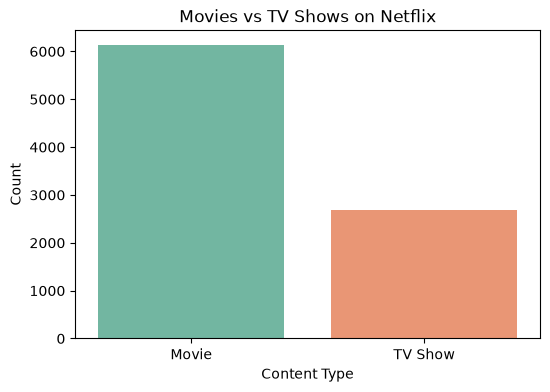

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="type", palette="Set2")
plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.show()

df["type"].value_counts()

**Insight:** Netflix contains more Movies than TV Shows. Movies dominate the platform library.

## Content Rating Distribution

**Question:** Which audience rating is most common?


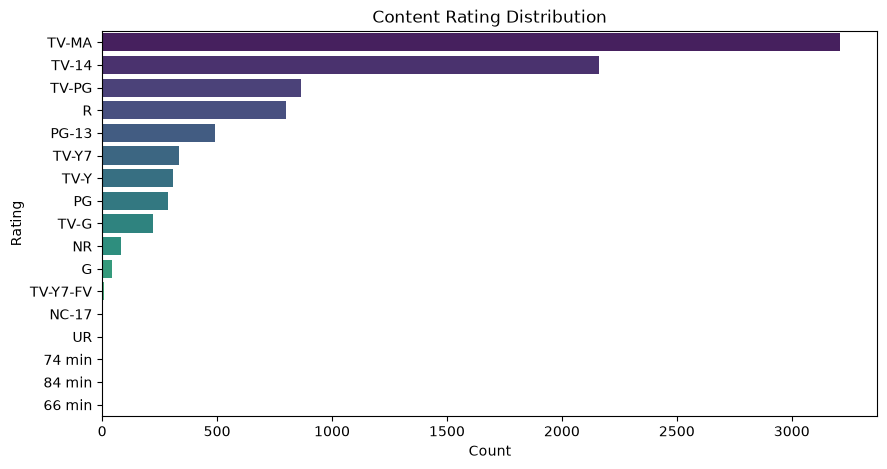

rating
TV-MA    3211
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64

In [7]:
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df,
    y="rating",
    order=df["rating"].value_counts().index,
    palette="viridis"
)
plt.title("Content Rating Distribution")
plt.xlabel("Count")
plt.ylabel("Rating")
plt.show()

df["rating"].value_counts().head(10)


**Insight:** TV-MA and TV-14 are among the most common ratings, showing that Netflix has many titles for mature and teen audiences.

## Top 10 Countries

**Question:** Which countries contribute the most Netflix content?


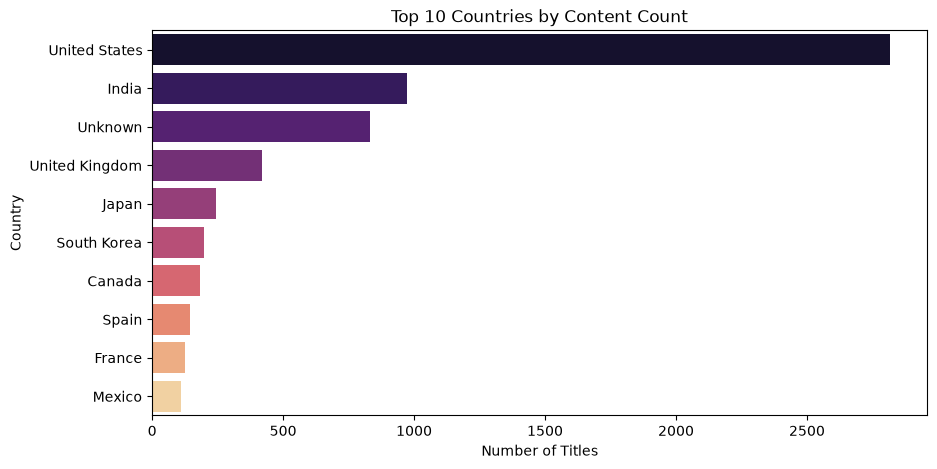

country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

In [8]:
top_countries = df["country"].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, palette="magma")
plt.title("Top 10 Countries by Content Count")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()

top_countries

**Insight:** The United States contributes the highest number of Netflix titles, followed by countries such as India and the United Kingdom.

## Release Year Distribution

**Question:** How has content production changed over time?

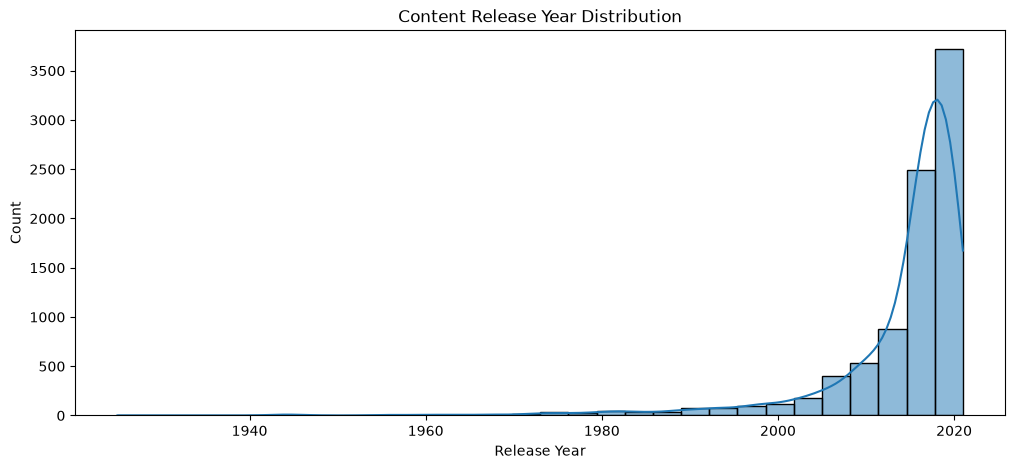

In [9]:
plt.figure(figsize=(12, 5))
sns.histplot(df["release_year"], bins=30, kde=True)
plt.title("Content Release Year Distribution")
plt.xlabel("Release Year")
plt.ylabel("Count")
plt.show()

**Insight:** Most titles were released after 2000, with strong growth after 2010.

## 6.5 Content Added by Year

**Question:** When did Netflix add the most content?

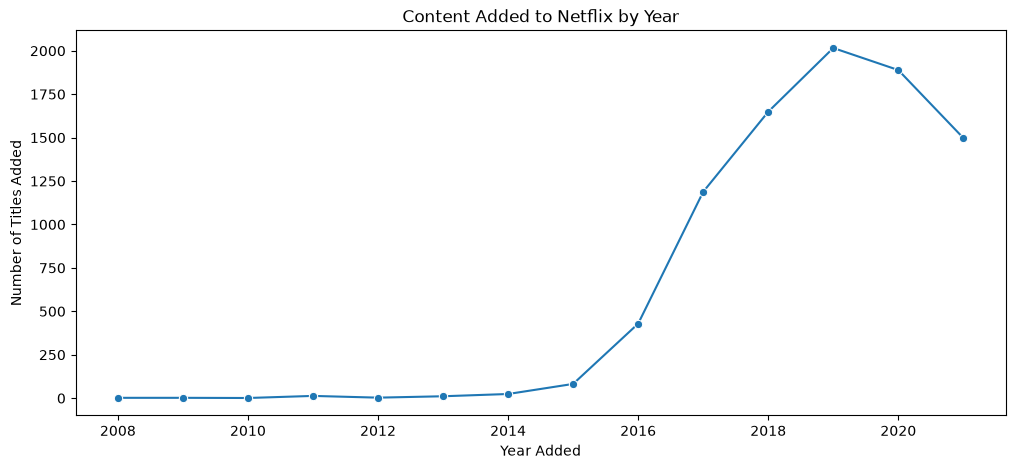

In [10]:
year_added = df["year_added"].value_counts().sort_index()

plt.figure(figsize=(12, 5))
sns.lineplot(x=year_added.index, y=year_added.values, marker="o")
plt.title("Content Added to Netflix by Year")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles Added")
plt.show()

**Insight:** Netflix expanded aggressively after 2015, with a peak around 2019.

## Movie vs TV Show Release Trend

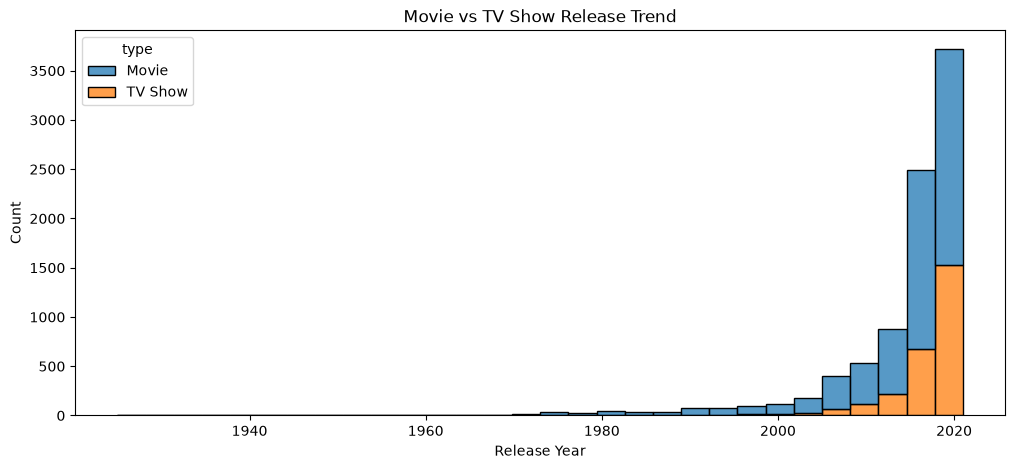

In [11]:
plt.figure(figsize=(12, 5))
sns.histplot(
    data=df,
    x="release_year",
    hue="type",
    bins=30,
    multiple="stack"
)
plt.title("Movie vs TV Show Release Trend")
plt.xlabel("Release Year")
plt.ylabel("Count")
plt.show()

## Movie Duration Analysis

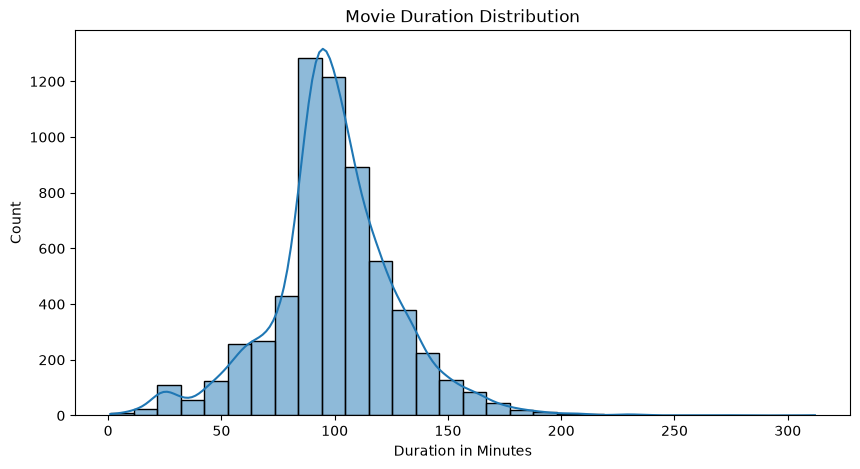

In [12]:
movies = df[df["type"] == "Movie"].copy()
movies["duration_num"] = movies["duration"].str.extract(r"(\d+)").astype(float)

plt.figure(figsize=(10, 5))
sns.histplot(movies["duration_num"], bins=30, kde=True)
plt.title("Movie Duration Distribution")
plt.xlabel("Duration in Minutes")
plt.ylabel("Count")
plt.show()

**Insight:** Most Netflix movies are around 80 to 120 minutes long.

## Genre Analysis

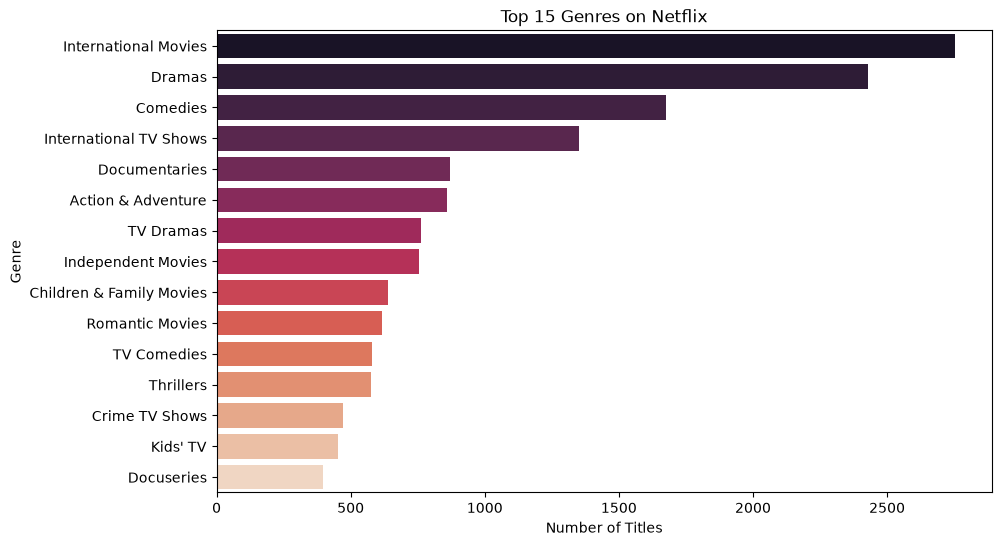

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
TV Comedies                  581
Thrillers                    577
Crime TV Shows               470
Kids' TV                     451
Docuseries                   395
Name: count, dtype: int64

In [13]:
genre_counts = (
    df["listed_in"]
    .str.split(", ")
    .explode()
    .value_counts()
    .head(15)
)

plt.figure(figsize=(10, 6))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette="rocket")
plt.title("Top 15 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.show()

genre_counts

**Insight:** International Movies, Dramas, and Comedies are major genres in Netflix content.

## Word Cloud from Descriptions

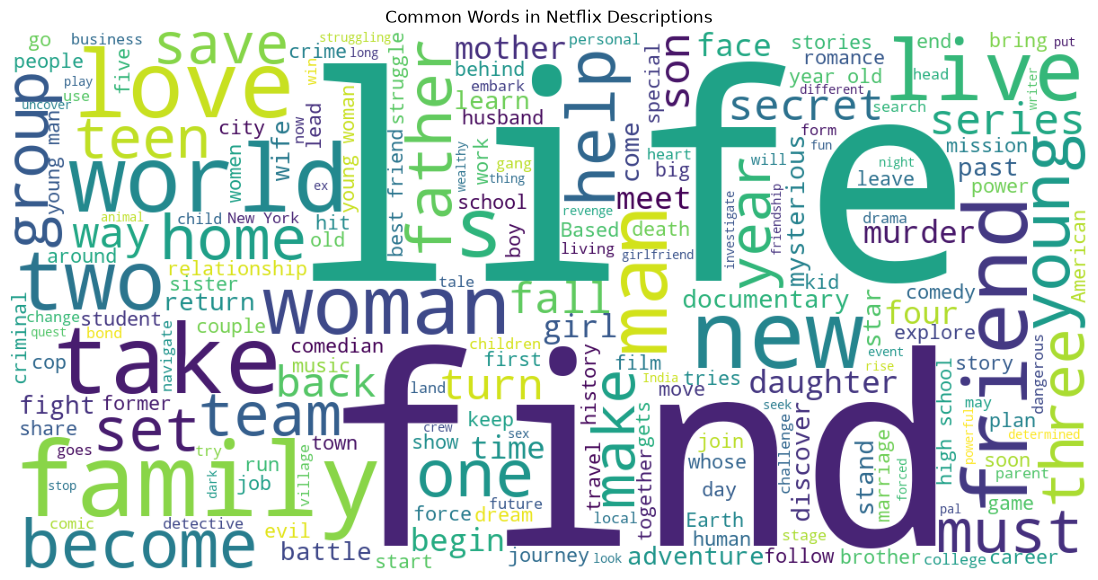

In [15]:
try:
    from wordcloud import WordCloud

    text = " ".join(df["description"].astype(str))

    wc = WordCloud(
        width=1200,
        height=600,
        background_color="white"
    ).generate(text)

    plt.figure(figsize=(15, 7))
    plt.imshow(wc)
    plt.axis("off")
    plt.title("Common Words in Netflix Descriptions")
    plt.show()
except ImportError:
    print("wordcloud is not installed. Run: pip install wordcloud")

## EDA Summary

Key findings:

1. Movies dominate Netflix content.
2. TV-MA and TV-14 are very common ratings.
3. The United States contributes the most content.
4. Most titles were released after 2000.
5. Netflix added a large amount of content after 2015.
6. Most movies are 80–120 minutes long.
7. International Movies, Dramas, and Comedies are dominant genres.